In [107]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import sklearn
from sklearn.metrics import classification_report

In [11]:
df_features, df_targets = sklearn.datasets.load_iris(return_X_y=True, as_frame=True)

In [17]:
df_features

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [18]:
df_targets

,target
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


# Step 1: Data Exploration

In [19]:
df_features.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [20]:
df_features.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3
149,5.9,3.0,5.1,1.8


In [21]:
df_targets.head()

,target
0,0
1,0
2,0
3,0
4,0


In [22]:
df_targets.tail()

,target
145,2
146,2
147,2
148,2
149,2


In [23]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [24]:
df_features.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


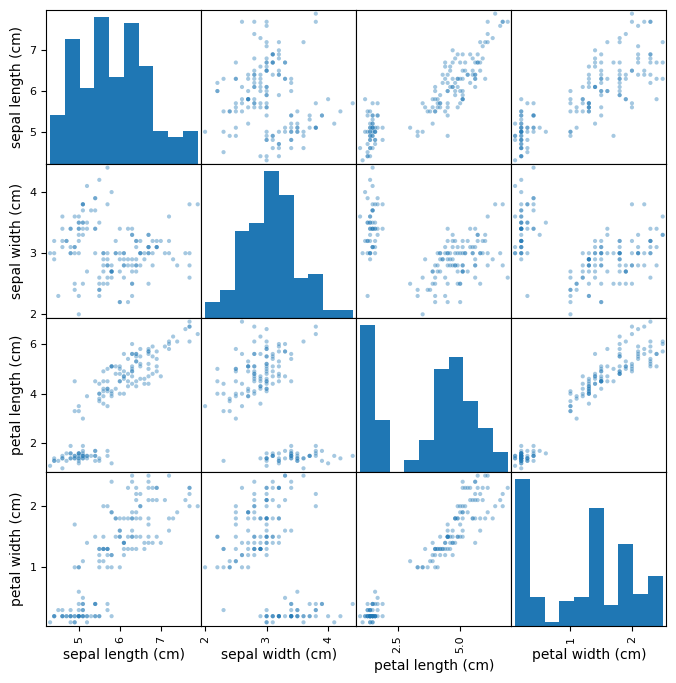

In [42]:
axes = pd.plotting.scatter_matrix(df_features, alpha=0.4, figsize=(8, 8))

# axes[0, 0].set_ylabel(df_features.columns[0], ha="right", va="bottom", rotation=60)
# axes[1, 0].set_ylabel(df_features.columns[1], ha="right", va="bottom", rotation=60)
# axes[2, 0].set_ylabel(df_features.columns[2], ha="right", va="bottom", rotation=60)
# axes[3, 0].set_ylabel(df_features.columns[3], ha="right", va="bottom", rotation=60)

### Figure 1: A scatter matrix of the four features of the Iris dataset. There are some correlations between the features.

# Step 2: Train Test Split

In [44]:
from sklearn.model_selection import train_test_split

In [53]:
X_train, X_test, Y_train, Y_test = train_test_split(df_features, df_targets, train_size=0.60, random_state=1415, stratify=df_targets)

In [54]:
X_train.shape, Y_train.shape

((90, 4), (90,))

In [55]:
X_test.shape, Y_test.shape

((60, 4), (60,))

# Step 3: Scaling

In [57]:
from sklearn.preprocessing import StandardScaler

In [69]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [73]:
np.mean(X_train_scaled, axis=0)

array([ 7.50017332e-16, -1.11114821e-15, -1.65299873e-16,  9.12850042e-17])

In [74]:
np.std(X_train_scaled, axis=0)

array([1., 1., 1., 1.])

In [75]:
np.mean(X_test_scaled, axis=0)

array([ 0.07193428, -0.0477145 ,  0.00512495,  0.02745412])

In [77]:
np.std(X_test_scaled, axis=0)

array([1.04226666, 1.02013844, 1.03561022, 1.03601785])

# Step 4: Make the model

In [95]:
import keras
from keras import layers
from keras import losses
from keras import metrics
from keras import optimizers

In [137]:
model = keras.models.Sequential()
model.add(layers.InputLayer(shape=X_train_scaled.shape[1:]))
model.add(layers.Dense(10, activation="relu"))
model.add(layers.Dense(10, activation="relu"))
model.add(layers.Dense(3, activation="softmax"))
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [138]:
loss = losses.SparseCategoricalCrossentropy()
optimizer = optimizers.Adam()
model.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])

# Step 5: Train the model

In [139]:
history = model.fit(
    X_train,
    Y_train,
    validation_split=0.20,
    epochs=100,
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 193ms/step - accuracy: 0.3720 - loss: 2.1946 - val_accuracy: 0.2222 - val_loss: 2.8061
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3563 - loss: 2.0107 - val_accuracy: 0.2222 - val_loss: 2.6723
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3837 - loss: 1.8879 - val_accuracy: 0.2222 - val_loss: 2.5464
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.3798 - loss: 1.8612 - val_accuracy: 0.2222 - val_loss: 2.4273
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.3485 - loss: 1.8460 - val_accuracy: 0.2222 - val_loss: 2.3195
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.3485 - loss: 1.7454 - val_accuracy: 0.2222 - val_loss: 2.2205
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3759 - loss: 1.6158 - val_accuracy: 0.2222 - val_loss: 2.1268
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.3329 - loss: 1.6050 - val_accuracy: 0.2222 - val_loss

# Step 6: Evaluate the model

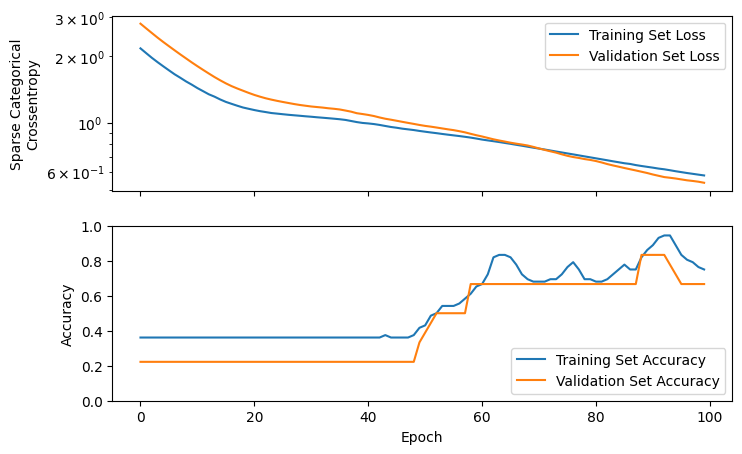

In [140]:
fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(8, 5))

axes[0].semilogy(history.history["loss"], label="Training Set Loss")
axes[0].semilogy(history.history["val_loss"], label="Validation Set Loss")
axes[0].legend(loc="upper right")

axes[1].plot(history.history["accuracy"], label="Training Set Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Validation Set Accuracy")
axes[1].legend(loc="lower right")
axes[1].set_ylim((0, 1))

axes[1].set_xlabel("Epoch")

axes[0].set_ylabel("Sparse Categorical\nCrossentropy")
axes[1].set_ylabel("Accuracy")

fig.show()